<a href="https://colab.research.google.com/github/Ramank510/CMP7005--Beijing-Air-Quality-Analysis/blob/main/CMP7005_PRAC1_S2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMP7005 — Programming for Data Analysis
## PRAC1
### Beijing Air Quality Analysis (2013–2017)
---
**Module:** CMP7005 | **Semester:** 2 | **Year:** 2025–2026

**Stations selected:** Dongsi, Guanyuan (Urban) | Dingling, Huairou (Suburban)

---

### Installing the libraries

In [1]:
# Install Streamlit (needed for the app in Task 4)
!pip install -q streamlit

# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
import zipfile

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Settings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
sns.set_style('whitegrid')

# Create folders
os.makedirs('data', exist_ok=True)
os.makedirs('figures', exist_ok=True)

print('✅ All libraries imported!')
print('✅ Folders created!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 89.9 MB/s eta 0:00:00
✅ All libraries imported!
✅ Folders created!


---
## Uploading the  Data


In [2]:
# Upload all the datasets (zip file)
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, f'data/{filename}')
    print(f'✅ Uploaded: {filename}')

Saving Assessment Data-20260306.zip to Assessment Data-20260306.zip
✅ Uploaded: Assessment Data-20260306.zip


In [3]:
# Extract the zip file
with zipfile.ZipFile('data/Assessment Data-20260306.zip', 'r') as zip_ref:
    zip_ref.extractall('data/')

print('✅ Zip extracted!')
print('\nCSV files available:')
for f in sorted(os.listdir('data/')):
    if f.endswith('.csv'):
        print(f'  - {f}')

✅ Zip extracted!

CSV files available:
  - PRSA_Data_Aotizhongxin_20130301-20170228.csv
  - PRSA_Data_Changping_20130301-20170228.csv
  - PRSA_Data_Dingling_20130301-20170228.csv
  - PRSA_Data_Dongsi_20130301-20170228.csv
  - PRSA_Data_Guanyuan_20130301-20170228.csv
  - PRSA_Data_Gucheng_20130301-20170228.csv
  - PRSA_Data_Huairou_20130301-20170228.csv
  - PRSA_Data_Nongzhanguan_20130301-20170228.csv
  - PRSA_Data_Shunyi_20130301-20170228.csv
  - PRSA_Data_Tiantan_20130301-20170228.csv
  - PRSA_Data_Wanliu_20130301-20170228.csv
  - PRSA_Data_Wanshouxigong_20130301-20170228.csv


---
## 1. Data Selection & Handling


### Station Selection Justification
Four stations were selected based on Xu & Zhang (2004) and Yao et al. (2015):

| Station | Type | Reason |
|---------|------|--------|
| Dongsi | Urban | Central Beijing, Dongcheng district — high traffic, high population density |
| Guanyuan | Urban | Xicheng district, inner city — near major roads and commercial activity |
| Dingling | Suburban | Changping district, north Beijing — semi-rural, near Ming Tombs |
| Huairou | Suburban | Huairou district, northernmost — mountainous, semi-rural, low industrial activity |

In [4]:
# Load 4 selected station CSV files
selected_stations = ['Dongsi', 'Guanyuan', 'Dingling', 'Huairou']
dataframes = []

for station in selected_stations:
    filepath = f'data/PRSA_Data_{station}_20130301-20170228.csv'
    df = pd.read_csv(filepath)
    print(f'✅ Loaded {station}: {df.shape[0]:,} rows, {df.shape[1]} columns')
    dataframes.append(df)

# Merge into one combined dataset
combined_df = pd.concat(dataframes, ignore_index=True)

# Create datetime column
combined_df['datetime'] = pd.to_datetime(combined_df[['year', 'month', 'day', 'hour']])

# Save combined dataset
combined_df.to_csv('data/combined_dataset.csv', index=False)

print(f'\n✅ Combined dataset: {combined_df.shape[0]:,} rows x {combined_df.shape[1]} columns')
print(f'📅 Date range: {combined_df["datetime"].min().date()} to {combined_df["datetime"].max().date()}')
print(f'🏙️  Stations: {list(combined_df["station"].unique())}')

✅ Loaded Dongsi: 35,064 rows, 18 columns
✅ Loaded Guanyuan: 35,064 rows, 18 columns
✅ Loaded Dingling: 35,064 rows, 18 columns
✅ Loaded Huairou: 35,064 rows, 18 columns

✅ Combined dataset: 140,256 rows x 19 columns
📅 Date range: 2013-03-01 to 2017-02-28
🏙️  Stations: ['Dongsi', 'Guanyuan', 'Dingling', 'Huairou']


---
## 2. Exploratory Data Analysis (EDA)


### 2.1 Data Understanding


In [5]:
# Dataset overview
print('=' * 50)
print('DATASET OVERVIEW')
print('=' * 50)
print(f'Rows    : {combined_df.shape[0]:,}')
print(f'Columns : {combined_df.shape[1]}')
print(f'\nColumn Names:')
for col in combined_df.columns:
    print(f'  - {col}')

DATASET OVERVIEW
Rows    : 140,256
Columns : 19

Column Names:
  - No
  - year
  - month
  - day
  - hour
  - PM2.5
  - PM10
  - SO2
  - NO2
  - CO
  - O3
  - TEMP
  - PRES
  - DEWP
  - RAIN
  - wd
  - WSPM
  - station
  - datetime


In [6]:
# Data types and missing values
print('=' * 50)
print('DATA TYPES & MISSING VALUES')
print('=' * 50)

info_df = pd.DataFrame({
    'Column'    : combined_df.columns,
    'Data Type' : combined_df.dtypes.values,
    'Missing'   : combined_df.isnull().sum().values,
    'Missing %' : (combined_df.isnull().sum().values / len(combined_df) * 100).round(2)
})
print(info_df.to_string(index=False))

DATA TYPES & MISSING VALUES
  Column      Data Type  Missing  Missing %
      No          int64        0       0.00
    year          int64        0       0.00
   month          int64        0       0.00
     day          int64        0       0.00
    hour          int64        0       0.00
   PM2.5        float64     3098       2.21
    PM10        float64     2415       1.72
     SO2        float64     2847       2.03
     NO2        float64     5133       3.66
      CO        float64     8384       5.98
      O3        float64     4202       3.00
    TEMP        float64      144       0.10
    PRES        float64      143       0.10
    DEWP        float64      146       0.10
    RAIN        float64      146       0.10
      wd         object      601       0.43
    WSPM        float64      120       0.09
 station         object        0       0.00
datetime datetime64[ns]        0       0.00


In [8]:
# Statistical summary
print('=' * 50)
print('STATISTICAL SUMMARY')
print('=' * 50)

numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

combined_df[numeric_cols].describe().round(2)

STATISTICAL SUMMARY


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,137158.00,137841.00,137409.00,135123.00,131872.00,136054.00,140112.00,140113.00,140110.00,140110.00,140136.00
mean,76.20,98.68,15.01,42.99,1130.21,60.33,13.35,1009.94,2.33,0.06,1.77
std,78.49,89.20,20.73,33.46,1061.42,56.21,11.51,10.48,13.86,0.83,1.25
min,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.40,-43.40,0.00,0.00
25%,19.00,32.00,2.00,17.00,400.00,16.00,3.00,1001.50,-9.20,0.00,0.90
50%,51.00,76.00,7.00,35.00,800.00,50.00,14.30,1009.50,2.90,0.00,1.40
75%,107.00,138.00,19.00,61.00,1400.00,84.00,23.10,1018.10,15.00,0.00,2.20
max,881.00,999.00,315.00,270.00,10000.00,1071.00,41.40,1042.00,29.10,72.50,12.90


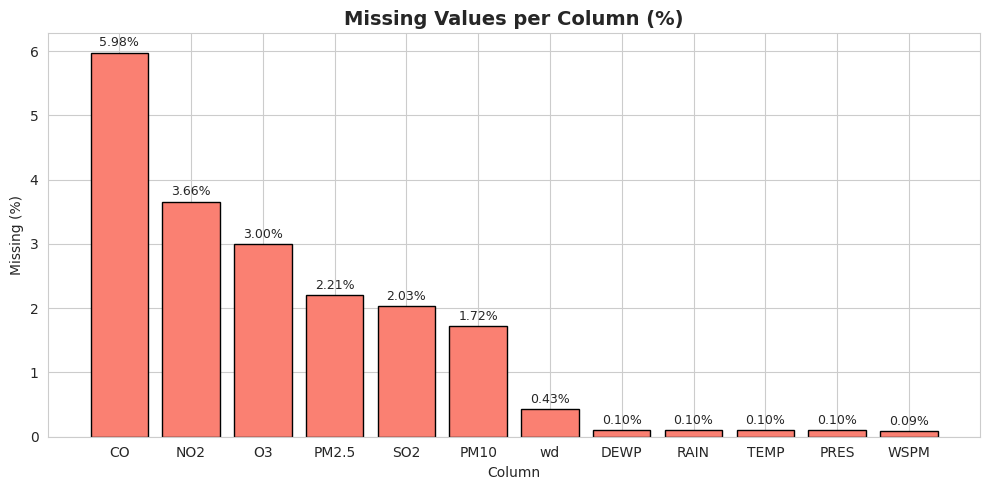

✅ Chart saved!


In [7]:
# Missing values chart
missing_pct = (combined_df.isnull().sum() / len(combined_df) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(missing_pct.index, missing_pct.values, color='salmon', edgecolor='black')

for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Missing Values per Column (%)', fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Missing (%)')
plt.tight_layout()
plt.savefig('figures/missing_values.png', dpi=150)
plt.show()
print('✅ Chart saved!')

**Initial Observations:**
- Combined dataset has **140,256 hourly records** across 4 years (March 2013 – February 2017)
- **CO has the most missing data (5.98%)** — likely due to sensor faults at some stations
- **Weather variables (TEMP, PRES, DEWP, RAIN) have very low missing rates (<0.10%)** — reliable sensors
- **PM2.5 mean (76.2 µg/m³) is over 5x the WHO guideline of 15 µg/m³** — serious air quality problem
- **PM2.5 max of 881 µg/m³** shows extreme pollution episodes exist in the data